<a href="https://colab.research.google.com/github/dhanushkumar-amk/BUILD-OWN-XYZ/blob/main/Bag_of_Words_Tokenizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Tokenize documents**

In [13]:
import re

def tokenize(text):
    text = text.lower()
    tokens = re.findall(r"\w+|[^\w\s]", text)
    return tokens

# Test
print(tokenize("I love pizza!"))

['i', 'love', 'pizza', '!']


## **Build a fixed, ordered vocabulary**

In [14]:
def build_vocabulary(documents):
    vocab_set = set()
    for doc in documents:
        tokens = tokenize(doc)
        vocab_set.update(tokens)

    # Fixed order (sorted for consistency)
    vocab_list = sorted(vocab_set)

    # token -> position mapping
    token_to_index = {token: idx for idx, token in enumerate(vocab_list)}

    return vocab_list, token_to_index

# Test
documents = [
    "I love pizza",
    "I love pizza pizza pizza",
    "I love pasta too"
]

vocab_list, token_to_index = build_vocabulary(documents)
print("Vocabulary:", vocab_list)
print("Vocab size:", len(vocab_list))
print(token_to_index)

Vocabulary: ['i', 'love', 'pasta', 'pizza', 'too']
Vocab size: 5
{'i': 0, 'love': 1, 'pasta': 2, 'pizza': 3, 'too': 4}


## **Word counting per document**

In [15]:
from collections import Counter

def count_words(document):
    tokens = tokenize(document)
    return Counter(tokens)

# Test
counts = count_words("I love pizza I love pizza pizza")
print(counts)

Counter({'pizza': 3, 'i': 2, 'love': 2})


## **Build the Bag-of-Words vector for one document**

In [16]:
def build_vector(document, token_to_index):
    vector = [0] * len(token_to_index)
    word_counts = count_words(document)

    for token, count in word_counts.items():
        if token in token_to_index:
            position = token_to_index[token]
            vector[position] = count
        # if token isn't in vocab, we just skip it (out-of-vocabulary)

    return vector

# Test
vec = build_vector("I love pizza I love pizza pizza", token_to_index)
print(vec)
print("Vocabulary order:", vocab_list)

[2, 2, 0, 3, 0]
Vocabulary order: ['i', 'love', 'pasta', 'pizza', 'too']


## **Build the document-term matrix**

In [17]:
def build_document_term_matrix(documents, token_to_index):
    matrix = []
    for doc in documents:
        vector = build_vector(doc, token_to_index)
        matrix.append(vector)
    return matrix

# Test
matrix = build_document_term_matrix(documents, token_to_index)

print("Vocabulary:", vocab_list)
for i, row in enumerate(matrix):
    print(f"Doc {i}: {row}")

Vocabulary: ['i', 'love', 'pasta', 'pizza', 'too']
Doc 0: [1, 1, 0, 1, 0]
Doc 1: [1, 1, 0, 3, 0]
Doc 2: [1, 1, 1, 0, 1]


## **Check sparsity**

In [18]:
def check_sparsity(vector):
    total = len(vector)
    non_zero = sum(1 for v in vector if v != 0)
    zero = total - non_zero
    sparsity_pct = (zero / total) * 100
    return sparsity_pct

for i, row in enumerate(matrix):
    pct = check_sparsity(row)
    print(f"Doc {i}: {pct:.1f}% zeros")

Doc 0: 40.0% zeros
Doc 1: 40.0% zeros
Doc 2: 20.0% zeros


## **Demonstrate word order loss**

In [19]:
sentence_a = "The dog bit the man"
sentence_b = "The man bit the dog"

# Build a temporary vocab just for this test
temp_vocab, temp_index = build_vocabulary([sentence_a, sentence_b])

vec_a = build_vector(sentence_a, temp_index)
vec_b = build_vector(sentence_b, temp_index)

print("Vocabulary:", temp_vocab)
print("Sentence A vector:", vec_a)
print("Sentence B vector:", vec_b)
print("Identical vectors?", vec_a == vec_b)

Vocabulary: ['bit', 'dog', 'man', 'the']
Sentence A vector: [1, 1, 1, 2]
Sentence B vector: [1, 1, 1, 2]
Identical vectors? True


## **Cosine similarity between documents**

In [20]:
import math

def cosine_similarity(vec_a, vec_b):
    dot_product = sum(a * b for a, b in zip(vec_a, vec_b))

    magnitude_a = math.sqrt(sum(a * a for a in vec_a))
    magnitude_b = math.sqrt(sum(b * b for b in vec_b))

    if magnitude_a == 0 or magnitude_b == 0:
        return 0.0  # avoid division by zero

    return dot_product / (magnitude_a * magnitude_b)

# Test: compare all documents pairwise
print("Vocabulary:", vocab_list)
for i, row in enumerate(matrix):
    print(f"Doc {i}: {row}")

print("\nPairwise similarities:")
for i in range(len(matrix)):
    for j in range(i + 1, len(matrix)):
        sim = cosine_similarity(matrix[i], matrix[j])
        print(f"Doc {i} vs Doc {j}: {sim:.3f}")

Vocabulary: ['i', 'love', 'pasta', 'pizza', 'too']
Doc 0: [1, 1, 0, 1, 0]
Doc 1: [1, 1, 0, 3, 0]
Doc 2: [1, 1, 1, 0, 1]

Pairwise similarities:
Doc 0 vs Doc 1: 0.870
Doc 0 vs Doc 2: 0.577
Doc 1 vs Doc 2: 0.302


## **Demonstrate the stop-word problem**

In [21]:
doc_cooking = "the recipe calls for the pan to be hot"
doc_basketball = "the player passed the ball to the guard"
doc_cooking_2 = "add the flour and the sugar to the bowl"

corpus = [doc_cooking, doc_basketball, doc_cooking_2]
vocab_list2, token_to_index2 = build_vocabulary(corpus)

matrix2 = build_document_term_matrix(corpus, token_to_index2)

print("Vocabulary:", vocab_list2)
for i, row in enumerate(matrix2):
    print(f"Doc {i}: {row}")

print("\nSimilarities (unrelated topics, but sharing stop words):")
sim_cooking_basketball = cosine_similarity(matrix2[0], matrix2[1])
sim_cooking_cooking = cosine_similarity(matrix2[0], matrix2[2])

print(f"Cooking vs Basketball (should be LOW): {sim_cooking_basketball:.3f}")
print(f"Cooking vs Cooking (should be HIGH):    {sim_cooking_cooking:.3f}")

Vocabulary: ['add', 'and', 'ball', 'be', 'bowl', 'calls', 'flour', 'for', 'guard', 'hot', 'pan', 'passed', 'player', 'recipe', 'sugar', 'the', 'to']
Doc 0: [0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 2, 1]
Doc 1: [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 3, 1]
Doc 2: [1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1]

Similarities (unrelated topics, but sharing stop words):
Cooking vs Basketball (should be LOW): 0.564
Cooking vs Cooking (should be HIGH):    0.545


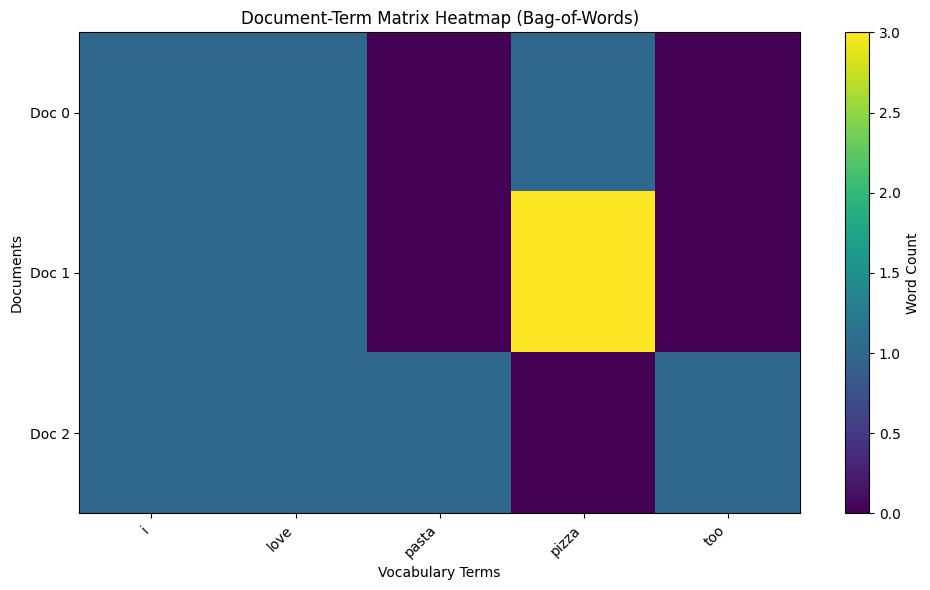

Document-Term Matrix (numerical representation):
Doc 0: [1 1 0 1 0]
Doc 1: [1 1 0 3 0]
Doc 2: [1 1 1 0 1]
Vocabulary order: ['i', 'love', 'pasta', 'pizza', 'too']


In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Convert the matrix to a numpy array for heatmap visualization
matrix_np = np.array(matrix)

plt.figure(figsize=(10, 6))
plt.imshow(matrix_np, cmap='viridis', aspect='auto', interpolation='nearest')
plt.colorbar(label='Word Count')

# Set x-axis ticks to vocabulary terms
plt.xticks(ticks=np.arange(len(vocab_list)), labels=vocab_list, rotation=45, ha='right')

# Set y-axis ticks to document indices
plt.yticks(ticks=np.arange(len(documents)), labels=[f'Doc {i}' for i in range(len(documents))])

plt.xlabel('Vocabulary Terms')
plt.ylabel('Documents')
plt.title('Document-Term Matrix Heatmap (Bag-of-Words)')
plt.tight_layout()
plt.show()

print("Document-Term Matrix (numerical representation):")
for i, row in enumerate(matrix_np):
    print(f"Doc {i}: {row}")
print("Vocabulary order:", vocab_list)